# 画像識別AIを作ろう

Kaggle班のやっていることを簡単に紹介します！

機械学習の一例を今回は紹介します。  
上のメニュータブからランタイム→ランタイムのタイプを変更→T4GPUを選択し保存して下さい。

今回は風景写真を6種類に分類するAIモデルを作りましょう。
**下のセルを上から順番に実行して下さい。**

**分類するクラス**
buildings（建物）/ forest（森）/ glacier（氷河）/ mountain（山）/ sea（海）/ street（街）

**全体の流れ**
1. データの読み込み・確認
2. データの前処理
3. モデルの構築（転移学習）
4. 学習
5. 評価

In [29]:
!pip install -q albumentations japanize-matplotlib
!pip install -U -q gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import random
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models
from torchvision.models import (
    EfficientNet_B0_Weights,
    EfficientNet_B2_Weights,
    ResNet18_Weights,
    ResNet50_Weights,
    MobileNet_V3_Large_Weights,
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, classification_report

In [30]:
if not os.path.exists("/content/intel-dataset-small"):
    print("ダウンロード中...")
    !gdown --fuzzy "https://drive.google.com/file/d/1E1MeXiG9usApc_tosXKHCcbzqLRJvU6L/view?usp=sharing" -O /content/intel-dataset-small.zip
    !unzip -q /content/intel-dataset-small.zip -d /content/
    print("完了")
else:
    print("既にダウンロード済みです")

既にダウンロード済みです


In [31]:
# ==================== Config ====================
TRAIN_DIR    = "/content/intel-dataset-small/seg_train/seg_train"
TEST_DIR     = "/content/intel-dataset-small/seg_test/seg_test"

IMG_SIZE     = 224
BATCH_SIZE   = 32
VAL_RATIO    = 0.3
EPOCHS       = 5
LR           = 0.0001
WEIGHT_DECAY = 0.0001
SEED         = 42
NUM_CLASSES  = 6

# 使用するモデルをここで切り替える
# "efficientnet_b0"    : 軽量・高精度。まずはこれ（デフォルト）
# "efficientnet_b2"    : B0より少し大きく精度も高め
# "resnet18"           : シンプルで速い。転移学習の入門に最適
# "resnet50"           : ResNet の中堅。精度と速度のバランスが良い
# "mobilenet_v3_large" : 非常に軽量。推論速度重視の場合に
MODEL_NAME = "efficientnet_b0"

# 損失関数
CRITERION = nn.CrossEntropyLoss()
# ================================================

In [32]:
# -------- visualization helpers --------
def show_sample_images(dataset_path, class_names, n=9):
    plt.figure(figsize=(10, 10))
    for i in range(n):
        cls   = random.choice(class_names)
        path  = os.path.join(dataset_path, cls)
        imgs  = [f for f in os.listdir(path) if not f.startswith('.')]
        img   = plt.imread(os.path.join(path, random.choice(imgs)))
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Class: {cls}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# データセットの読み込みと確認

**Intel Image Classification** データセットを使用します。

建物・森・氷河・山・海・街の **6クラス** からなる風景写真データセットです。

| データ | 枚数 | 用途 |
|---|---|---|
| 訓練データ | 約2,000枚 | モデルのパラメータ更新に使用 |
| テストデータ | 約600枚 | 学習後の最終評価に使用 |

下の節では各クラスからランダムに画像を表示します。

どんなデータを学習させるのか確認してみましょう。

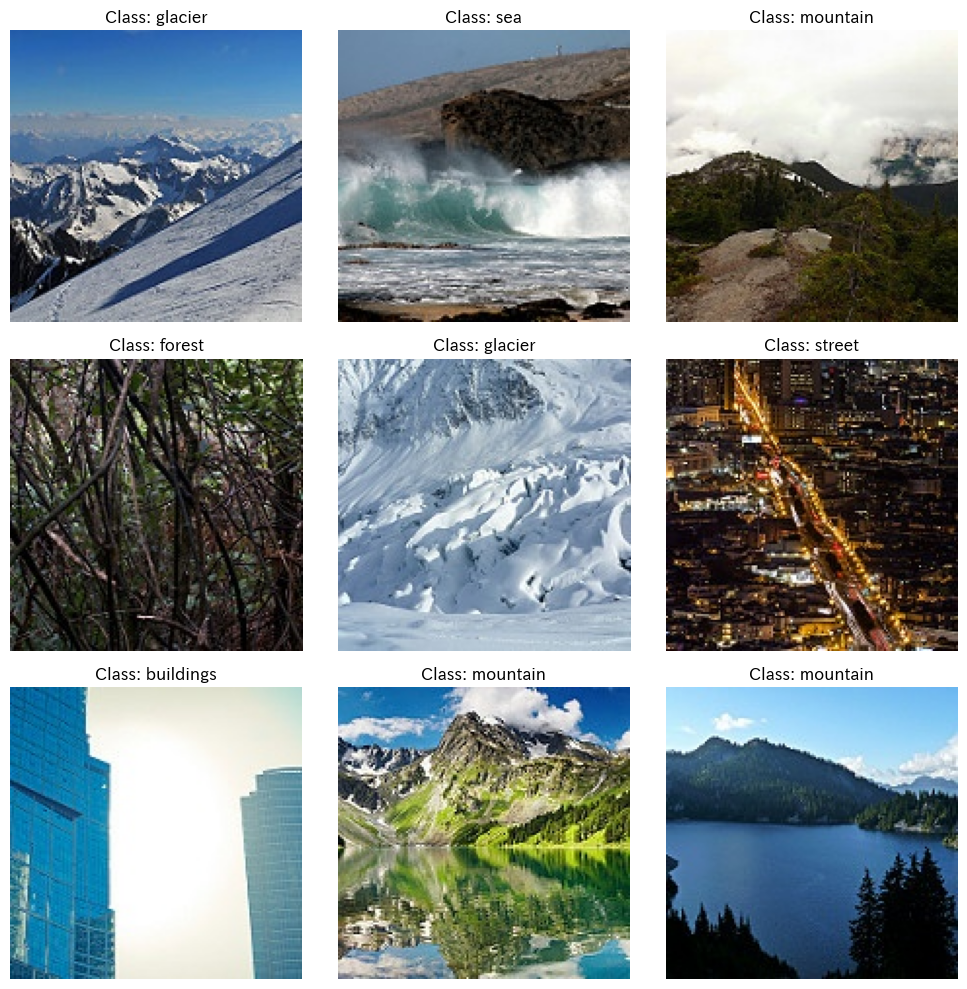

In [33]:
_class_names = sorted([d for d in os.listdir(TRAIN_DIR) if not d.startswith('.')])
show_sample_images(TRAIN_DIR, _class_names)

各クラスの画像枚数を棒グラフで確認します。

クラス間の枚数が大きく偏っていると、枚数が多いクラスばかりを正解するモデルになってしまいます（**クラス不均衡問題**）。
そう言った時は学習の仕方にも工夫が必要になります。評価指標の選択やSMOTE、FocalLossなどで対処します。気になる人は調べてみて下さい。
このデータセットではバランスよく揃っています。

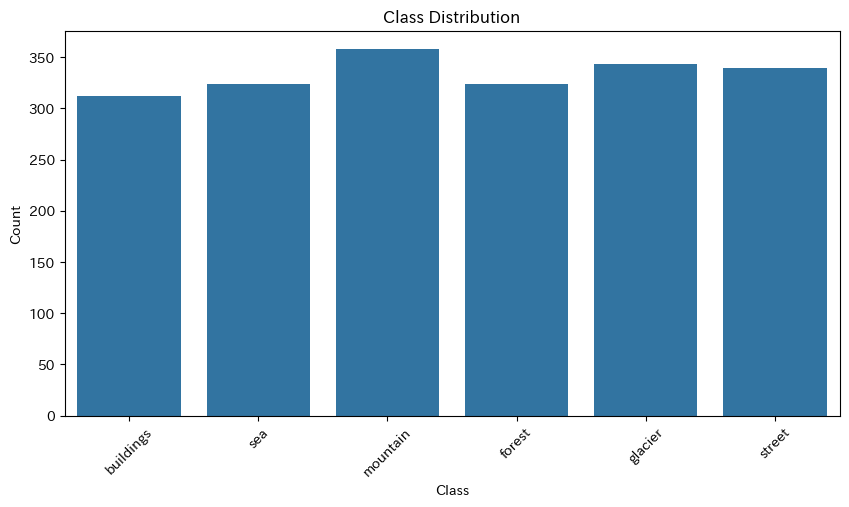

In [34]:
class_counts = {
    cls: len([f for f in os.listdir(os.path.join(TRAIN_DIR, cls)) if not f.startswith('.')])
    for cls in os.listdir(TRAIN_DIR) if not cls.startswith('.')
}
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])

plt.figure(figsize=(10, 5))
sns.barplot(x="Class", y="Count", data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# データの前処理

AIに画像を渡す前に、形式を統一する必要があります。
ここでは **albumentations** というライブラリを使って前処理・データ拡張を行います。

| 処理 | 内容 |
|---|---|
| Resize(224, 224) | 画像サイズを224×224ピクセルに統一 |
| HorizontalFlip | 水平方向にランダムで反転（データ拡張） |
| RandomBrightnessContrast | 明るさ・コントラストをランダムに変化（データ拡張） |
| Normalize(...) | ImageNetの統計値で標準化。事前学習済みモデルに合わせた必須処理 |
| ToTensorV2() | PyTorchのTensor形式に変換 |

**データ拡張（Data Augmentation）とは？**
画像を反転・回転・明暗変化させることで、水増しした学習データとして使う技術です。
少ないデータでも汎化性能が上がる効果があります。

**触ってみよう**: 拡張の種類やパラメータを変えると精度が変わります（Config と関数定義セルを編集）
- `HorizontalFlip(p=0.5)` → `p=1.0` にすると必ず反転
- `RandomBrightnessContrast(p=0.2)` → `p=0.5` に増やすと効果が強くなる
- `A.Rotate(limit=30, p=0.3)` を追加すると回転も加わる

結果画像をクリックすると多少大きく表示されます。

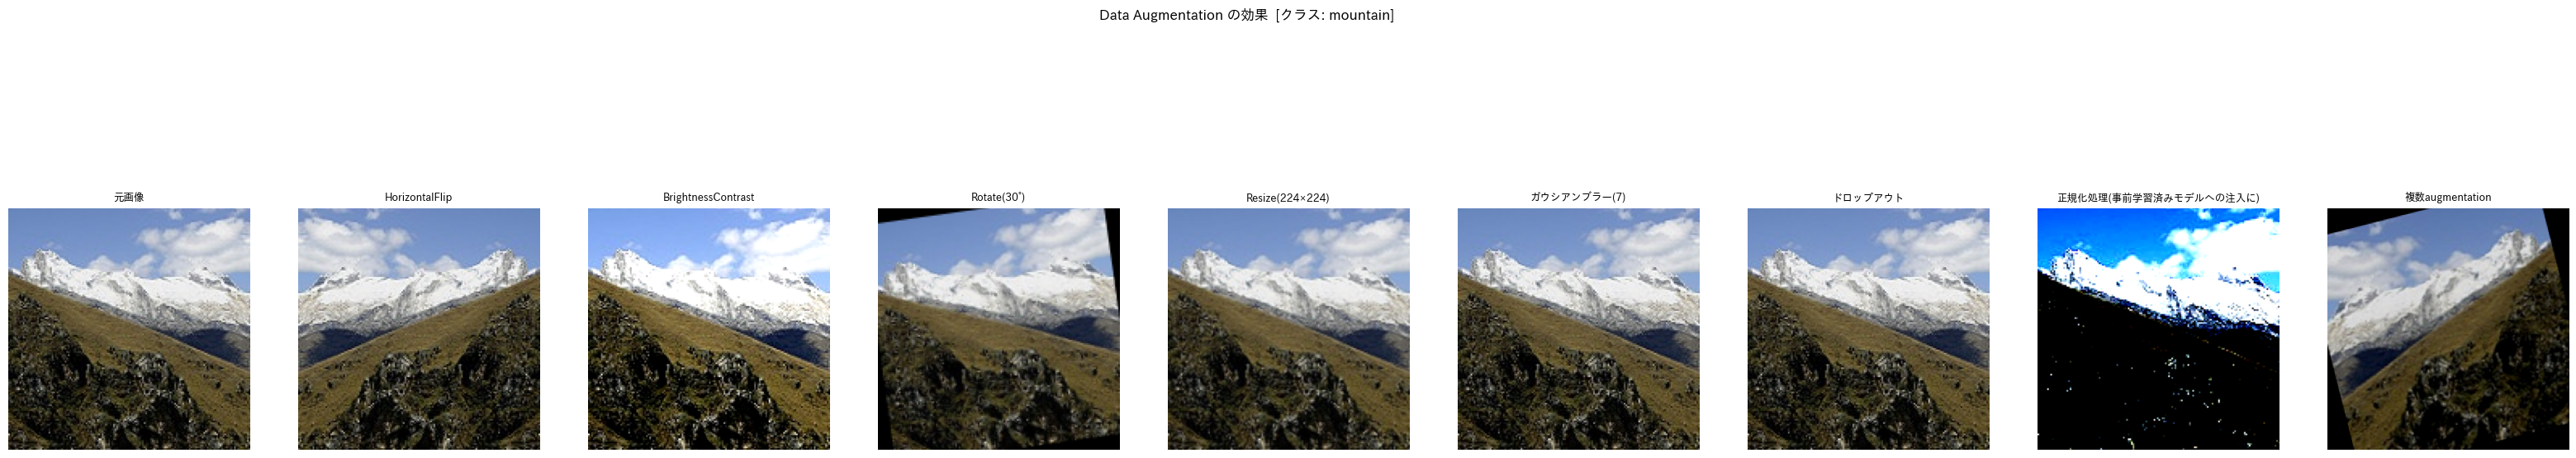

<Figure size 10000x4000 with 0 Axes>

In [35]:
# ランダムに1枚選んで各augmentationの効果を並べて表示
# これはalbummentationsの拡張の可視化用のセルです。
_cls      = random.choice(sorted([d for d in os.listdir(TRAIN_DIR) if not d.startswith('.')]))
_img_path = os.path.join(TRAIN_DIR, _cls,
                random.choice([f for f in os.listdir(os.path.join(TRAIN_DIR, _cls))
                                if not f.startswith('.')]))
_img = np.array(plt.imread(_img_path))

_augs = [
    ("元画像",                   None),
    ("HorizontalFlip",           A.HorizontalFlip(p=1.0)),
    ("BrightnessContrast",       A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=1.0)),
    ("Rotate(30°)",              A.Rotate(limit=30, p=1.0)),
    ("Resize(224×224)",          A.Resize(IMG_SIZE, IMG_SIZE)),
    ("ガウシアンブラー(7)",          A.MotionBlur(blur_limit=7)),
    ("ドロップアウト",          A.CoarseDropout(max_holes=8, max_height=8, max_width=8)),
    ("正規化処理(事前学習済みモデルへの注入に)",        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))),
    ("複数augmentation",       A.Compose([
                                    A.Resize(IMG_SIZE, IMG_SIZE),
                                    A.HorizontalFlip(p=1.0),
                                    A.RandomBrightnessContrast(p=1.0),
                                    A.Rotate(limit=30, p=1.0),
                                ])),
]

fig, axes = plt.subplots(1, len(_augs), figsize=(40, 8))
for ax, (name, aug) in zip(axes, _augs):
    img_show = _img if aug is None else aug(image=_img)["image"]
    ax.imshow(img_show)
    ax.set_title(name, fontsize=9)
    ax.axis("off")

plt.suptitle(f"Data Augmentation の効果  [クラス: {_cls}]", fontsize=12)
plt.figure(figsize=(100, 40))
plt.tight_layout()
plt.show()

In [36]:
# -------- transforms --------
class AlbumentationsWrapper:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, img):
        img = np.array(img)
        return self.transform(image=img)['image']


def get_transforms():
    train_transform = AlbumentationsWrapper(A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]))
    val_transform = AlbumentationsWrapper(A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]))
    return train_transform, val_transform

訓練データを **訓練用（70%）** と **検証用（30%）** に分割します。

**なぜ分割するの？**

同じデータでテストすると「答えを覚えただけ」のモデルでも高得点になってしまいます。  
モデルを学習させるとは、これは森だよ これは海だよ って教えまくることです。  
そうするとモデルが「こんな感じの特徴があったら海ちゃうかなあ」と学習を進めます。(青かったら海 角張った形状が見えたら建物 みたいな).  
そして、それが正しいかを調べるためにモデルは答えの知らない検証データを解き、間違っていた部分を修正します。  
それを繰り返して、いい感じに問題が解けるまで学習を繰り返します。
答えを知っているデータで検証をしても当然意味はありません。なので、検証データと訓練データに分ける必要があります。

難しかったら、答えを見てから問題を解く試験は意味ないよねって思ってください。それはモデルも同じです。

| データ | 割合 | 役割 |
|---|---|---|
| 訓練データ | 70% | パラメータの更新に使用 |
| 検証データ | 30% | 各エポック後に過学習チェック |
| テストデータ | 別途 | 学習完了後の最終評価 |

**過学習**  
データを繰り返し解きすぎたモデルはそれしか解けない人になってしまいます。  
学習データにない画像が出てきた時にわからなくなってしまいます。  
この現象を過学習といいます。なので、**表現力の低い学習になっていないか**はモデルを作る時に非常に注意しないといけないポイントになります。

In [37]:
# -------- dataloader --------
def get_dataloaders(train_transform, val_transform):
    full_train = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
    test_ds    = datasets.ImageFolder(root=TEST_DIR,  transform=val_transform)

    val_size   = int(VAL_RATIO * len(full_train))
    train_size = len(full_train) - val_size
    train_ds, valid_ds = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    valid_ds.dataset = copy.copy(full_train)
    valid_ds.dataset.transform = val_transform

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    class_names = full_train.classes
    print(f"Train: {len(train_ds)} / Validation: {len(valid_ds)} / Test: {len(test_ds)}")
    return train_loader, valid_loader, test_loader, class_names



# モデルの構築

**転移学習（Transfer Learning）** を使います。

すでに大量のデータで学習済みのモデルを土台として使う手法です。

1から毎回学習をしていては時間がかかります。赤ちゃんに微分を教えるより、高校生に微分を教える方が楽ちんです。  
すでにある程度賢いモデルを持ってきて、そのモデルに今回のタスクを教えようってことです。  

今回はそのある程度賢いモデルとして、**EfficientNet-B0**（ImageNetの100万枚以上で学習済み）をベースに使います。  

具体的にやっていることとしては、今回はモデルの最後の部分だけ調整します。
この辺は雰囲気だけ理解して、講習会等を通して、細かい理解を深めていきましょう！

```
[ EfficientNet-B0 の特徴抽出部分 ]  ← 固定（触らない）
           ↓
[ 全結合層 512 → 256 → 128 → 6 ]  ← ここだけ学習する
```

In [38]:
# -------- model --------
def _make_head(in_features):
    """分類ヘッド（全モデル共通）"""
    return nn.Sequential(
        nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(512, 256),         nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(256, 128),         nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(128, NUM_CLASSES)
    )

def build_model(device):
    if MODEL_NAME == "efficientnet_b0":
        base = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        for p in base.parameters(): p.requires_grad = False
        base.classifier = _make_head(base.classifier[1].in_features)

    elif MODEL_NAME == "efficientnet_b2":
        base = models.efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
        for p in base.parameters(): p.requires_grad = False
        base.classifier = _make_head(base.classifier[1].in_features)

    elif MODEL_NAME == "resnet18":
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        for p in base.parameters(): p.requires_grad = False
        base.fc = _make_head(base.fc.in_features)

    elif MODEL_NAME == "resnet50":
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        for p in base.parameters(): p.requires_grad = False
        base.fc = _make_head(base.fc.in_features)

    elif MODEL_NAME == "mobilenet_v3_large":
        base = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        for p in base.parameters(): p.requires_grad = False
        base.classifier[3] = _make_head(base.classifier[3].in_features)

    else:
        raise ValueError(f"未対応のモデル: {MODEL_NAME}")

    print(f"モデル: {MODEL_NAME}")
    return base.to(device)

# 学習関数
最適化アルゴリズムと損失関数を設定します。

**損失関数（CrossEntropyLoss）**: 予測がどれだけ正解からずれているかを数値化します。
この値が小さくなるようにパラメータを更新するのが学習の本質です。

**最適化アルゴリズム（AdamW）**: パラメータをどう更新するかを決める方法です。

**触ってみよう**: Config の `LR`（学習率）を変えると学習速度・精度が変わります
- `LR=0.0001` 小さいほど慎重に学習（精度は上がりやすいが遅い）
- `LR=0.001`  大きいほど速く学習（不安定になることも）

In [39]:
# -------- training --------
def train_model(model, train_loader, valid_loader, optimizer, criterion, device):
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    for epoch in range(EPOCHS):
        # 訓練フェーズ
        model.train()
        train_loss, train_correct, n_train = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * imgs.size(0)
            _, preds       = torch.max(out, 1)
            train_correct += (preds == labels).sum().item()
            n_train       += labels.size(0)

        # 検証フェーズ
        model.eval()
        val_loss, val_correct, n_val = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in valid_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                val_loss    += loss.item() * imgs.size(0)
                _, preds     = torch.max(out, 1)
                val_correct += (preds == labels).sum().item()
                n_val       += labels.size(0)

        t_loss, t_acc = train_loss / n_train, train_correct / n_train
        v_loss, v_acc = val_loss   / n_val,   val_correct   / n_val
        history["loss"].append(t_loss);         history["accuracy"].append(t_acc)
        history["val_loss"].append(v_loss);     history["val_accuracy"].append(v_acc)
        print(f"Epoch [{epoch+1}/{EPOCHS}] "
              f"Loss: {t_loss:.4f} Acc: {t_acc:.4f} "
              f"Val Loss: {v_loss:.4f} Val Acc: {v_acc:.4f}")

    return history


# -------- evaluation --------
def evaluate_model(model, test_loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, preds = torch.max(model(imgs), 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    return y_true, y_pred

## 学習開始

各エポックで以下を繰り返します。

```
訓練フェーズ: 画像を入力 → 予測 → 正解と比較（損失計算） → パラメータ更新
検証フェーズ: 学習に使っていない画像で現在の精度を確認
```

**触ってみよう**: Config の `EPOCHS` の値を変えると最大学習回数が変わります
- `EPOCHS = 5`  学習データを五周繰り返しときます。
- `EPOCHS = 10` 10周ときます。あまり増やしすぎると過学習の原因になります。

In [40]:
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用デバイス: {device}")

    train_transform, val_transform = get_transforms()
    train_loader, valid_loader, test_loader, class_names = get_dataloaders(
        train_transform, val_transform
    )

    model     = build_model(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history        = train_model(model, train_loader, valid_loader, optimizer, CRITERION, device)
    y_true, y_pred = evaluate_model(model, test_loader, device)

    return model, class_names, history, y_true, y_pred


model, class_names, history, y_true, y_pred = main()

使用デバイス: cuda
Train: 1400 / Validation: 600 / Test: 600
モデル: efficientnet_b0
Epoch [1/5] Loss: 1.7848 Acc: 0.1786 Val Loss: 1.7629 Val Acc: 0.2133
Epoch [2/5] Loss: 1.7300 Acc: 0.3671 Val Loss: 1.6244 Val Acc: 0.6617
Epoch [3/5] Loss: 1.4679 Acc: 0.5593 Val Loss: 1.1330 Val Acc: 0.7717
Epoch [4/5] Loss: 1.0332 Acc: 0.6264 Val Loss: 0.7879 Val Acc: 0.7900
Epoch [5/5] Loss: 0.8323 Acc: 0.6907 Val Loss: 0.6357 Val Acc: 0.7967


# 結果の確認

学習が終わったら、テストデータ（学習中に一度も見ていない画像）で最終評価を行います。

In [41]:
# -------- visualization helpers --------
def show_sample_images(dataset_path, class_names, n=9):
    plt.figure(figsize=(10, 10))
    for i in range(n):
        cls   = random.choice(class_names)
        path  = os.path.join(dataset_path, cls)
        imgs  = [f for f in os.listdir(path) if not f.startswith('.')]
        img   = plt.imread(os.path.join(path, random.choice(imgs)))
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"クラス: {cls}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## 学習曲線

エポックごとの精度・ロスの推移を確認します。

**グラフの見方**
- 訓練・検証ともに精度が上がっていれば良好
- 訓練精度は高いのに検証精度が低い → **過学習**のサイン
- 両方が低いまま → モデルや学習率の見直しが必要

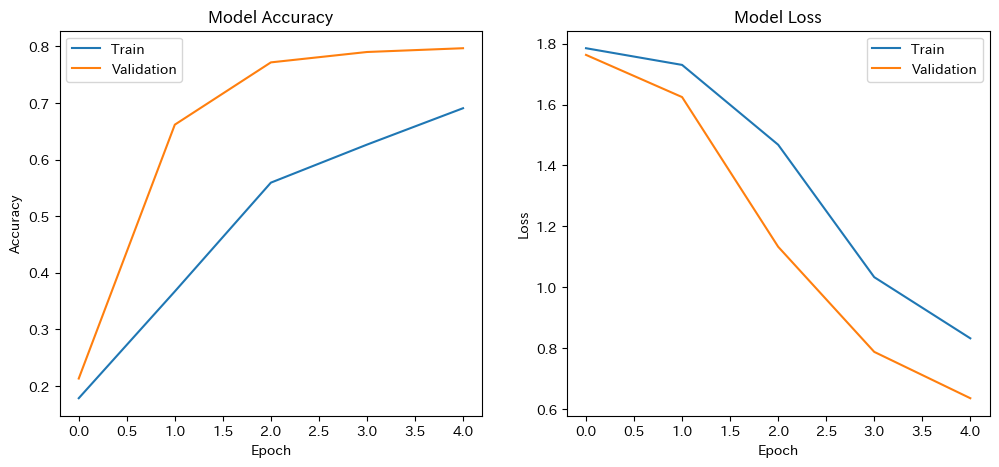

In [42]:
History = pd.DataFrame(history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(History["accuracy"])
plt.plot(History["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(History["loss"])
plt.plot(History["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])

plt.show()

## 混同行列（Confusion Matrix）

どのクラスをどのクラスと間違えたかを表します。

- **対角線上の数値が大きい** → 正確に分類できている
- **対角線以外に大きな数値** → そのクラスを間違えやすい

例えば「building（建物）をstreet（道）と間違えやすい」といった傾向がわかります。

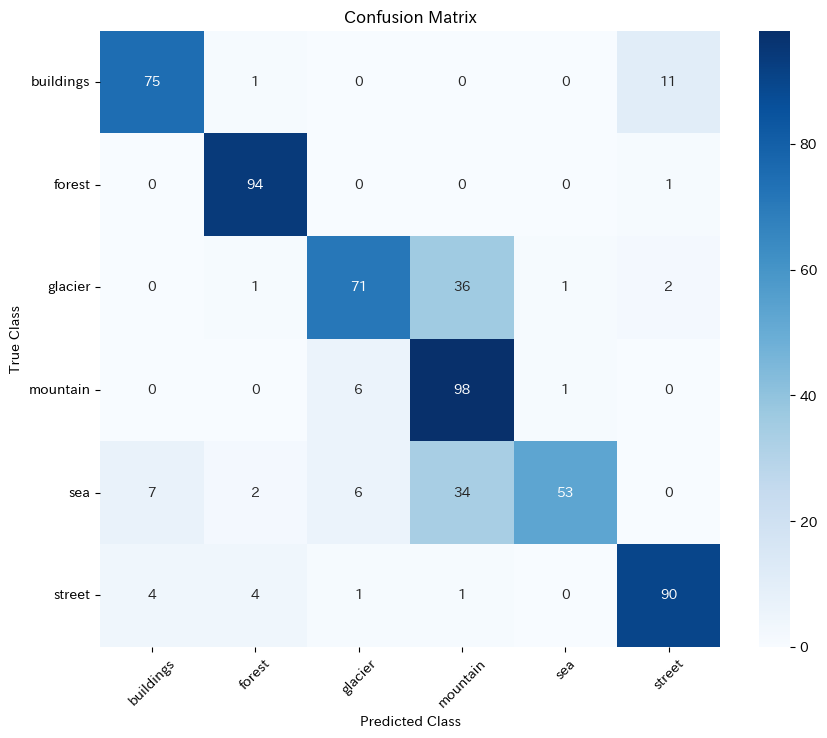

In [43]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## 分類レポート

クラスごとの詳細なスコアです。

| 指標 | 意味 |
|---|---|
| precision（適合率） | 「このクラスと予測したもの」のうち実際に正しかった割合 |
| recall（再現率） | 「実際にこのクラス」のうち正しく予測できた割合 |
| f1-score | precisionとrecallのバランスを示す総合スコア |
| accuracy | 全体の正解率 |

In [44]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.87      0.86      0.87        87
      forest       0.92      0.99      0.95        95
     glacier       0.85      0.64      0.73       111
    mountain       0.58      0.93      0.72       105
         sea       0.96      0.52      0.68       102
      street       0.87      0.90      0.88       100

    accuracy                           0.80       600
   macro avg       0.84      0.81      0.80       600
weighted avg       0.84      0.80      0.80       600

